# 2035 Full-Year PCM Analysis

**Scenario:** GTEP Stage 3 solution — 278 generators, 123 buses, PTDF formulation
**Period:** January 1 – December 31, 2035 (365 days, 8,760 hours)
**Simulation:** Prescient UC+ED with day-ahead RUC and real-time SCED

---

> **WARNING — Known Data Issue**
>
> NUC and COAL generators have **ZERO dispatch** across all 8,760 hours due to corrupted
> `HR_avg_0` values in `gen.csv`. The startup cost at PMin computed by Egret
> (`Fuel Price × HR_avg_0 × 0.001 × PMin`) is astronomical for these units, making them
> uneconomic. This analysis documents results **as-is**. A corrected re-run is recommended
> before publication.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_ROOT = Path(os.path.abspath('')).parent / 'data' / 'retirement_allowed_no_extreme_half_load'
RESULTS_DIR = DATA_ROOT / 'Prescient_2_2035' / 'results'
GEN_CSV = DATA_ROOT / 'Prescient_2_2035' / 'gen.csv'
OUTPUT_DIR = Path(os.path.abspath(''))
OUTPUT_SUFFIX = '_2035'

print(f'Results dir: {RESULTS_DIR}')
print(f'Results exist: {RESULTS_DIR.exists()}')
print(f'Output dir: {OUTPUT_DIR}')


def _prescient_output_to_df(file_name):
    """Load Prescient output CSV and combine Date/Hour/Minute into Datetime."""
    df = pd.read_csv(file_name)
    if 'Minute' in df.columns:
        df['Datetime'] = (
            pd.to_datetime(df['Date'])
            + pd.to_timedelta(df['Hour'], 'hour')
            + pd.to_timedelta(df['Minute'], 'minute')
        )
        df.drop(columns=['Date', 'Hour', 'Minute'], inplace=True)
    elif 'Hour' in df.columns:
        df['Datetime'] = (
            pd.to_datetime(df['Date'])
            + pd.to_timedelta(df['Hour'], 'hour')
        )
        df.drop(columns=['Date', 'Hour'], inplace=True)
    else:
        df['Datetime'] = pd.to_datetime(df['Date'])
        df.drop(columns=['Date'], inplace=True)
    cols = df.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    return df[cols]


def make_lmp_csv(lmp_path, bus_details_path, bus_name, output_dir='.'):
    """Extract LMP for a single bus and append to the wide-format LMP CSV."""
    out_csv = os.path.join(output_dir, f'Bus_LMP{OUTPUT_SUFFIX}.csv')
    bdf = _prescient_output_to_df(bus_details_path)
    bdf = bdf[bdf['Bus'] == bus_name][['Datetime', 'LMP', 'LMP DA']]
    bdf.set_index('Datetime', inplace=True)
    bdf = bdf.rename(columns={'LMP': f'{bus_name}_LMP', 'LMP DA': f'{bus_name}_LMP DA'})

    if lmp_path is None:
        bdf.to_csv(out_csv)
    else:
        lmp_df = pd.read_csv(lmp_path).set_index('Datetime')
        if f'{bus_name}_LMP' in lmp_df.columns:
            return
        bdf_aligned = bdf.reindex(lmp_df.index)
        lmp_df = pd.concat([lmp_df, bdf_aligned], axis=1)
        lmp_df.to_csv(out_csv)


def make_dispatch_csv(dispatch_path, gen_details_path, gen_name, gen_type,
                      other_info=None, output_dir='.'):
    """Extract dispatch for a single generator and append to wide-format CSV."""
    out_csv = os.path.join(output_dir, f'Generator_Dispatch{OUTPUT_SUFFIX}.csv')
    gdf = _prescient_output_to_df(gen_details_path)

    if gen_type == 'fossil':
        info_list = ['Datetime', 'Dispatch', 'Dispatch DA']
    elif gen_type == 'renew':
        info_list = ['Datetime', 'Output', 'Output DA']
    else:
        raise ValueError(f'Unknown gen_type: {gen_type}')

    if other_info is not None:
        info_list.extend(other_info)

    gdf_filtered = gdf[gdf['Generator'] == gen_name]
    if len(gdf_filtered) == 0:
        try:
            gdf_filtered = gdf[gdf['Generator'] == int(gen_name)]
        except (ValueError, TypeError):
            pass
    if len(gdf_filtered) == 0:
        print(f'WARNING: Generator {gen_name} not found')
        return

    gdf_filtered = gdf_filtered[info_list]
    gdf_filtered.set_index('Datetime', inplace=True)
    new_col_name = {col: f'{gen_name}_{col}' for col in info_list if col != 'Datetime'}
    gdf_filtered = gdf_filtered.rename(columns=new_col_name)

    if dispatch_path is None:
        gdf_filtered.to_csv(out_csv)
    else:
        dispatch_df = pd.read_csv(dispatch_path).set_index('Datetime')
        first_col = list(new_col_name.values())[0]
        if first_col in dispatch_df.columns:
            return
        gdf_aligned = gdf_filtered.reindex(dispatch_df.index)
        dispatch_df = pd.concat([dispatch_df, gdf_aligned], axis=1)
        dispatch_df.to_csv(out_csv)

## 1. Load Raw Data

In [2]:
# ── Load simulation outputs ───────────────────────────────────────────────
overall = pd.read_csv(RESULTS_DIR / 'overall_simulation_output.csv')
daily = pd.read_csv(RESULTS_DIR / 'daily_summary.csv', parse_dates=['Date'])
hourly = _prescient_output_to_df(RESULTS_DIR / 'hourly_summary.csv')
bus_df = _prescient_output_to_df(RESULTS_DIR / 'bus_detail.csv')
therm = _prescient_output_to_df(RESULTS_DIR / 'thermal_detail.csv')
renew = _prescient_output_to_df(RESULTS_DIR / 'renewables_detail.csv')
gen = pd.read_csv(GEN_CSV)

print(f'Overall:       {len(overall):>12,} rows')
print(f'Daily:         {len(daily):>12,} rows  (expected 365)')
print(f'Hourly:        {len(hourly):>12,} rows  (expected 8,760)')
print(f'Bus detail:    {len(bus_df):>12,} rows  (expected 1,077,480)')
print(f'Thermal:       {len(therm):>12,} rows  (expected 1,305,240)')
print(f'Renewables:    {len(renew):>12,} rows  (expected 1,130,040)')
print(f'Generators:    {len(gen):>12,} rows  (expected 278)')

# Validate dimensions
assert len(daily) == 365, f'Expected 365 daily rows, got {len(daily)}'
assert len(hourly) == 8760, f'Expected 8760 hourly rows, got {len(hourly)}'
assert len(bus_df) == 1_077_480, f'Expected 1,077,480 bus rows, got {len(bus_df)}'
assert len(therm) == 1_305_240, f'Expected 1,305,240 thermal rows, got {len(therm)}'
assert len(renew) == 1_130_040, f'Expected 1,130,040 renew rows, got {len(renew)}'
assert len(gen) == 278, f'Expected 278 generators, got {len(gen)}'
print('\nAll dimension checks passed.')

Overall:                  1 rows
Daily:                  365 rows  (expected 365)
Hourly:               8,760 rows  (expected 8,760)
Bus detail:       1,077,480 rows  (expected 1,077,480)
Thermal:          1,305,240 rows  (expected 1,305,240)
Renewables:       1,130,040 rows  (expected 1,130,040)
Generators:             278 rows  (expected 278)

All dimension checks passed.


## 2. CRITICAL: NUC/COAL Zero Dispatch — Root Cause

The `HR_avg_0` column in `gen.csv` contains astronomically large values for NUC and COAL
generators. Egret computes startup cost at PMin as `Fuel Price × HR_avg_0 × 0.001 × PMin`,
which makes these units prohibitively expensive to commit.

In [3]:
# ── Show HR_avg_0 corruption ──────────────────────────────────────────────
hr_check = gen[['GEN UID', 'Unit Type', 'Fuel', 'Fuel Price $/MMBTU',
                'PMin MW', 'PMax MW', 'HR_avg_0', 'HR_incr_1']].copy()
hr_check['Cost_at_PMin'] = (
    hr_check['Fuel Price $/MMBTU'] * hr_check['HR_avg_0'] * 0.001 * hr_check['PMin MW']
)
hr_check['Expected_MC'] = hr_check['Fuel Price $/MMBTU'] * hr_check['HR_incr_1'] * 0.001

print('HR_avg_0 by Unit Type (sample):')
print('=' * 90)
for utype in ['NUC', 'COAL', 'CT']:
    subset = hr_check[hr_check['Unit Type'] == utype].head(3)
    if len(subset) > 0:
        print(f'\n{utype}:')
        print(subset[['GEN UID', 'HR_avg_0', 'HR_incr_1', 'Cost_at_PMin',
                       'Expected_MC']].to_string(index=False))

# ── Confirm zero dispatch for NUC and COAL ────────────────────────────────
nuc_coal_ids = gen[gen['Unit Type'].isin(['NUC', 'COAL'])]['GEN UID'].values
nuc_coal_dispatch = therm[therm['Generator'].isin(nuc_coal_ids)]['Dispatch'].sum()
print(f'\nTotal NUC+COAL dispatch across 8,760 hours: {nuc_coal_dispatch:.2f} MW')
print(f'NUC+COAL generators: {len(nuc_coal_ids)}')

if nuc_coal_dispatch < 0.01:
    print('\nCONFIRMED: NUC and COAL have zero dispatch.')
    print('RECOMMENDATION: Fix HR_avg_0 values in gen.csv and re-run simulation.')
else:
    print(f'\nUNEXPECTED: NUC/COAL dispatched {nuc_coal_dispatch:.1f} MW total.')

HR_avg_0 by Unit Type (sample):

NUC:
GEN UID     HR_avg_0    HR_incr_1  Cost_at_PMin  Expected_MC
      1 3.598445e+06 16453.390510  1.176385e+06     7.378403
     93 4.011008e+06 18882.988104  1.273536e+06     7.378403

COAL:
GEN UID      HR_avg_0   HR_incr_1  Cost_at_PMin  Expected_MC
     26 309438.202200 8910.960674 301876.122342     18.93942
    165 235080.000000 5875.018989 267226.807668     18.93942
    175 113467.078652 3803.035593 144467.096082     18.93942

CT:
GEN UID    HR_avg_0   HR_incr_1  Cost_at_PMin  Expected_MC
      2 9177.903930  927.388027  20620.177725     22.80128
      3 6286.462882 1360.395148   7459.913072     22.80128
      4 3543.406114  886.216140   4824.589177     22.80128

Total NUC+COAL dispatch across 8,760 hours: 0.00 MW
NUC+COAL generators: 14

CONFIRMED: NUC and COAL have zero dispatch.
RECOMMENDATION: Fix HR_avg_0 values in gen.csv and re-run simulation.


## 3. Annual Metrics Dashboard

In [4]:
# ── Parse overall metrics ─────────────────────────────────────────────────
o = overall.iloc[0]

# Load-weighted LMP
_LOW_DEMAND_MW = 1.0
bus_df['_wt_lmp'] = bus_df['Demand'] * bus_df['LMP DA']
_total_demand = bus_df['Demand'].sum()
if _total_demand < _LOW_DEMAND_MW:
    warnings.warn('Total demand < 1 MW — using simple mean as fallback')
    lw_lmp = bus_df['LMP DA'].mean()
else:
    lw_lmp = bus_df['_wt_lmp'].sum() / _total_demand
bus_df.drop(columns='_wt_lmp', inplace=True)

# Dashboard
metrics = {
    'Total Demand (TWh)': o['Total demand'] / 1e6,
    'Total Fixed Costs ($B)': o['Total fixed costs'] / 1e9,
    'Total Generation Costs ($B)': o['Total generation costs'] / 1e9,
    'Total Costs ($B)': o['Total costs'] / 1e9,
    'Load-Weighted LMP ($/MWh)': lw_lmp,
    'Cumulative Avg Price ($/MWh)': o['Cumulative average price'],
    'Renewables Penetration (%)': o['Overall renewables penetration rate'],
    'Total Load Shedding (MWh)': o['Total load shedding'],
    'Total Curtailment (MWh)': o['Total renewables curtailment'],
    'Total Reserve Shortfall (MWh)': o['Total reserve shortfall'],
    'Peak Demand (MW)': o['Maximum observed demand'],
    'Total On/Offs': o['Total on/offs'],
    'Total Energy Payments ($B)': o['Total energy payments'] / 1e9,
    'Total Reserve Payments ($M)': o['Total reserve payments'] / 1e6,
}

print('2035 Full-Year Annual Metrics Dashboard')
print('=' * 55)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'  {k:<40s} {v:>12,.2f}')
    else:
        print(f'  {k:<40s} {v:>12,}')

# Sanity flags
print('\n── Sanity Flags ──')
flags = []
if o['Total load shedding'] > 0:
    flags.append(f'LOAD SHEDDING: {o["Total load shedding"]:.2f} MWh')
if o['Total renewables curtailment'] > 0:
    flags.append(f'CURTAILMENT: {o["Total renewables curtailment"]:.2f} MWh')
if lw_lmp < 10 or lw_lmp > 60:
    flags.append(f'LMP out of normal range: ${lw_lmp:.2f}/MWh')
if o['Total reserve shortfall'] > 100:
    flags.append(f'RESERVE SHORTFALL: {o["Total reserve shortfall"]:.1f} MWh')
if not flags:
    print('  All basic checks pass')
else:
    for f in flags:
        print(f'  {f}')

2035 Full-Year Annual Metrics Dashboard
  Total Demand (TWh)                             238.71
  Total Fixed Costs ($B)                           2.23
  Total Generation Costs ($B)                      2.60
  Total Costs ($B)                                 4.84
  Load-Weighted LMP ($/MWh)                       30.48
  Cumulative Avg Price ($/MWh)                    20.27
  Renewables Penetration (%)                      29.24
  Total Load Shedding (MWh)                        3.45
  Total Curtailment (MWh)                          0.00
  Total Reserve Shortfall (MWh)                  591.37
  Peak Demand (MW)                            39,818.53
  Total On/Offs                               16,803.00
  Total Energy Payments ($B)                       6.94
  Total Reserve Payments ($M)                      1.22

── Sanity Flags ──
  LOAD SHEDDING: 3.45 MWh
  RESERVE SHORTFALL: 591.4 MWh


## 4. Extract Standardized Output Files

In [5]:
# ── Build Bus_LMP_2035.csv ────────────────────────────────────────────────
bus_names = sorted(bus_df['Bus'].unique())
print(f'Building Bus_LMP{OUTPUT_SUFFIX}.csv for {len(bus_names)} buses...')

lmp_csv = str(OUTPUT_DIR / f'Bus_LMP{OUTPUT_SUFFIX}.csv')
bus_detail_path = str(RESULTS_DIR / 'bus_detail.csv')

for idx, bus_name in enumerate(bus_names):
    if idx == 0:
        make_lmp_csv(lmp_path=None, bus_details_path=bus_detail_path,
                     bus_name=bus_name, output_dir=str(OUTPUT_DIR))
    else:
        make_lmp_csv(lmp_path=lmp_csv, bus_details_path=bus_detail_path,
                     bus_name=bus_name, output_dir=str(OUTPUT_DIR))
    if (idx + 1) % 30 == 0:
        print(f'  ... processed {idx + 1}/{len(bus_names)} buses')

df_lmp_check = pd.read_csv(lmp_csv)
print(f'\nBus_LMP{OUTPUT_SUFFIX}.csv: {df_lmp_check.shape[0]} rows x {df_lmp_check.shape[1]} cols')
print(f'Expected: 8,760 rows x {len(bus_names) * 2 + 1} cols')

# ── Build Generator_Dispatch_2035.csv ─────────────────────────────────────
thermal_gens = sorted(therm['Generator'].unique())
renew_gens = sorted(renew['Generator'].unique())
print(f'\nBuilding Generator_Dispatch{OUTPUT_SUFFIX}.csv for {len(thermal_gens)} thermal + {len(renew_gens)} renewable gens...')

dispatch_csv = str(OUTPUT_DIR / f'Generator_Dispatch{OUTPUT_SUFFIX}.csv')
thermal_detail_path = str(RESULTS_DIR / 'thermal_detail.csv')
renew_detail_path = str(RESULTS_DIR / 'renewables_detail.csv')

thermal_other_info = ['Unit Cost', 'Unit State']
for idx, gn in enumerate(thermal_gens):
    if idx == 0:
        make_dispatch_csv(dispatch_path=None, gen_details_path=thermal_detail_path,
                          gen_name=gn, gen_type='fossil',
                          other_info=thermal_other_info, output_dir=str(OUTPUT_DIR))
    else:
        make_dispatch_csv(dispatch_path=dispatch_csv, gen_details_path=thermal_detail_path,
                          gen_name=gn, gen_type='fossil',
                          other_info=thermal_other_info, output_dir=str(OUTPUT_DIR))
    if (idx + 1) % 30 == 0:
        print(f'  ... processed {idx + 1}/{len(thermal_gens)} thermal gens')

renew_other_info = ['Curtailment']
for gn in renew_gens:
    make_dispatch_csv(dispatch_path=dispatch_csv, gen_details_path=renew_detail_path,
                      gen_name=gn, gen_type='renew',
                      other_info=renew_other_info, output_dir=str(OUTPUT_DIR))

df_disp_check = pd.read_csv(dispatch_csv)
print(f'\nGenerator_Dispatch{OUTPUT_SUFFIX}.csv: {df_disp_check.shape[0]} rows x {df_disp_check.shape[1]} cols')

Building Bus_LMP_2035.csv for 123 buses...


  ... processed 30/123 buses


  ... processed 60/123 buses


  ... processed 90/123 buses


  ... processed 120/123 buses


...

  ... processed 30/149 thermal gens


  ... processed 60/149 thermal gens


  ... processed 90/149 thermal gens


  ... processed 120/149 thermal gens



Generator_Dispatch_2035.csv: 8760 rows x 984 cols


In [6]:
# ── Build PCM_result_2035.json ────────────────────────────────────────────
df_lmp = pd.read_csv(lmp_csv)
df_dispatch = pd.read_csv(dispatch_csv)

LMP_result = {}
for bus_name in bus_names:
    lmp_col = f'{bus_name}_LMP'
    lmp_da_col = f'{bus_name}_LMP DA'
    if lmp_da_col not in df_lmp.columns:
        continue
    LMP_result[str(bus_name)] = {
        'LMP_DA_mean': float(df_lmp[lmp_da_col].mean()),
        'LMP_DA_median': float(df_lmp[lmp_da_col].median()),
        'LMP_DA_min': float(df_lmp[lmp_da_col].min()),
        'LMP_DA_max': float(df_lmp[lmp_da_col].max()),
        'LMP_mean': float(df_lmp[lmp_col].mean()),
        'LMP_median': float(df_lmp[lmp_col].median()),
        'LMP_min': float(df_lmp[lmp_col].min()),
        'LMP_max': float(df_lmp[lmp_col].max()),
    }

dispatch_result = {}
for gn in thermal_gens:
    gn_str = str(gn)
    da_col = f'{gn_str}_Dispatch DA'
    rt_col = f'{gn_str}_Dispatch'
    if da_col in df_dispatch.columns:
        dispatch_result[gn_str] = {
            'type': 'thermal',
            'tot_Dispatch_DA': float(df_dispatch[da_col].sum()),
            'tot_Dispatch': float(df_dispatch[rt_col].sum()),
        }

for gn in renew_gens:
    gn_str = str(gn)
    da_col = f'{gn_str}_Output DA'
    rt_col = f'{gn_str}_Output'
    if da_col in df_dispatch.columns:
        entry = {
            'type': 'renewable',
            'tot_Output_DA': float(df_dispatch[da_col].sum()),
            'tot_Output': float(df_dispatch[rt_col].sum()),
        }
        curt_col = f'{gn_str}_Curtailment'
        if curt_col in df_dispatch.columns:
            entry['tot_Curtailment'] = float(df_dispatch[curt_col].sum())
        dispatch_result[gn_str] = entry

result_summary = {'LMP': LMP_result, 'Dispatch': dispatch_result}
pcm_path = str(OUTPUT_DIR / f'PCM_result{OUTPUT_SUFFIX}.json')
with open(pcm_path, 'w') as f:
    json.dump(result_summary, f, indent=2)

print(f'LMP stats for {len(LMP_result)} buses')
print(f'Dispatch stats for {len(dispatch_result)} generators')
print(f'Saved to {pcm_path}')

LMP stats for 123 buses
Dispatch stats for 278 generators
Saved to /Users/yilu/Documents/GitHub/idaes-gtep/gtep/pcm_analysis/PCM_result_2035.json


## 5. Generation Mix by Fuel Type

In [7]:
# ── Merge thermal dispatch with gen.csv ───────────────────────────────────
gen_info = gen[['GEN UID', 'Unit Type', 'Fuel', 'Fuel Price $/MMBTU',
                'PMax MW', 'PMin MW', 'HR_incr_1']].copy()

# Thermal generation by fuel type
therm_merged = therm.merge(gen_info, left_on='Generator', right_on='GEN UID', how='left')
therm_merged['Month'] = therm_merged['Datetime'].dt.month
therm_merged['Quarter'] = therm_merged['Datetime'].dt.quarter

# Annual thermal generation (GWh)
therm_annual = therm_merged.groupby('Unit Type')['Dispatch'].sum() / 1e3

# Renewable generation by type
renew_info = gen[gen['Unit Type'].isin(['PV', 'WIND', 'HYDRO'])][['GEN UID', 'Unit Type', 'PMax MW']]
renew_merged = renew.merge(renew_info, left_on='Generator', right_on='GEN UID', how='left')
renew_merged['Month'] = renew_merged['Datetime'].dt.month
renew_merged['Quarter'] = renew_merged['Datetime'].dt.quarter
renew_annual = renew_merged.groupby('Unit Type')['Output'].sum() / 1e3

# Combined annual generation
all_gen_gwh = pd.concat([therm_annual, renew_annual]).sort_values(ascending=False)
total_gen = all_gen_gwh.sum()

# Installed capacity by type
therm_cap = gen[gen['Unit Type'].isin(['NUC', 'COAL', 'CT'])].groupby('Unit Type')['PMax MW'].sum()
renew_cap = gen[gen['Unit Type'].isin(['PV', 'WIND', 'HYDRO'])].groupby('Unit Type')['PMax MW'].sum()
all_cap = pd.concat([therm_cap, renew_cap])

# Capacity factor
n_hours = 8760
cf = (all_gen_gwh * 1e3) / (all_cap * n_hours) * 100

print('Annual Generation Mix')
print('=' * 70)
print(f'{"Type":<8s} {"Gen (GWh)":>12s} {"Share (%)":>10s} {"Cap (MW)":>10s} {"CF (%)":>8s}')
print('-' * 70)
for utype in all_gen_gwh.index:
    gwh = all_gen_gwh[utype]
    share = gwh / total_gen * 100
    cap = all_cap.get(utype, 0)
    c = cf.get(utype, 0)
    print(f'{utype:<8s} {gwh:>12,.1f} {share:>9.1f}% {cap:>10,.0f} {c:>7.1f}%')
print('-' * 70)
print(f'{"TOTAL":<8s} {total_gen:>12,.1f} {100.0:>9.1f}% {all_cap.sum():>10,.0f}')

# ── Quarterly breakdown ───────────────────────────────────────────────────
print('\n\nQuarterly Generation (GWh)')
print('=' * 60)
therm_q = therm_merged.groupby(['Quarter', 'Unit Type'])['Dispatch'].sum() / 1e3
renew_q = renew_merged.groupby(['Quarter', 'Unit Type'])['Output'].sum() / 1e3
q_all = pd.concat([therm_q.unstack(fill_value=0), renew_q.unstack(fill_value=0)], axis=1)
q_all = q_all.reindex(columns=all_gen_gwh.index, fill_value=0)
print(q_all.round(1).to_string())

Annual Generation Mix
Type        Gen (GWh)  Share (%)   Cap (MW)   CF (%)
----------------------------------------------------------------------
CT          168,916.0      70.8%     62,707    30.8%
WIND         55,706.5      23.3%      8,470    75.1%
PV           14,089.0       5.9%      2,798    57.5%
COAL              0.0       0.0%     13,918     0.0%
NUC               0.0       0.0%      5,139     0.0%
----------------------------------------------------------------------
TOTAL       238,711.5     100.0%     93,032


Quarterly Generation (GWh)
Unit Type       CT     WIND      PV  COAL  NUC
Quarter                                       
1          39284.3  13359.1  2914.7   0.0  0.0
2          37602.5  15789.8  4309.4   0.0  0.0
3          48973.8  14110.7  4246.7   0.0  0.0
4          43055.3  12446.8  2618.3   0.0  0.0


In [ ]:
# ── Stacked area: daily generation by fuel type ───────────────────────────
COLORS = {'NUC': '#e41a1c', 'COAL': '#555555', 'CT': '#ff7f00',
          'WIND': '#4daf4a', 'PV': '#ffff33', 'HYDRO': '#377eb8'}

# Daily thermal generation
therm_merged['Date'] = therm_merged['Datetime'].dt.normalize()
daily_therm = therm_merged.groupby(['Date', 'Unit Type'])['Dispatch'].sum().unstack(fill_value=0) / 1e3

# Daily renewable generation
renew_merged['Date'] = renew_merged['Datetime'].dt.normalize()
daily_renew = renew_merged.groupby(['Date', 'Unit Type'])['Output'].sum().unstack(fill_value=0) / 1e3

daily_mix = pd.concat([daily_therm, daily_renew], axis=1).fillna(0)
# Order: baseload first, then peakers, then renewables
col_order = [c for c in ['NUC', 'COAL', 'CT', 'HYDRO', 'WIND', 'PV'] if c in daily_mix.columns]
daily_mix = daily_mix[col_order]

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(daily_mix.index, *[daily_mix[c] for c in col_order],
             labels=col_order, colors=[COLORS[c] for c in col_order], alpha=0.85)
ax.set_ylabel('Daily Generation (GWh)')
ax.set_title('2035 Daily Generation by Fuel Type')
ax.legend(loc='upper left', ncol=len(col_order))
ax.set_xlim(daily_mix.index[0], daily_mix.index[-1])

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

# ── Stacked bar: quarterly generation ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
q_plot = q_all.reindex(columns=col_order, fill_value=0)
q_plot.plot(kind='bar', stacked=True, ax=ax, color=[COLORS[c] for c in col_order], alpha=0.85)
ax.set_ylabel('Generation (GWh)')
ax.set_title('2035 Quarterly Generation by Fuel Type')
ax.set_xlabel('Quarter')
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. LMP Analysis

Load-Weighted LMP Summary ($/MWh)
  Annual mean:   $   30.43
  Median:        $   27.74
  Std dev:       $   10.38
  Min:           $   -2.83
  Max:           $  259.16
  Negative hours: 1 (0.01%)

Monthly Average LW-LMP ($/MWh):
  Month  1: $30.96
  Month  2: $31.74
  Month  3: $31.90
  Month  4: $29.91
  Month  5: $30.45
  Month  6: $29.70
  Month  7: $29.38
  Month  8: $29.68
  Month  9: $31.15
  Month 10: $30.28
  Month 11: $30.24
  Month 12: $29.89


/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_64831/4037881284.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(q_data, labels=['Q1', 'Q2', 'Q3', 'Q4'], patch_artist=True)


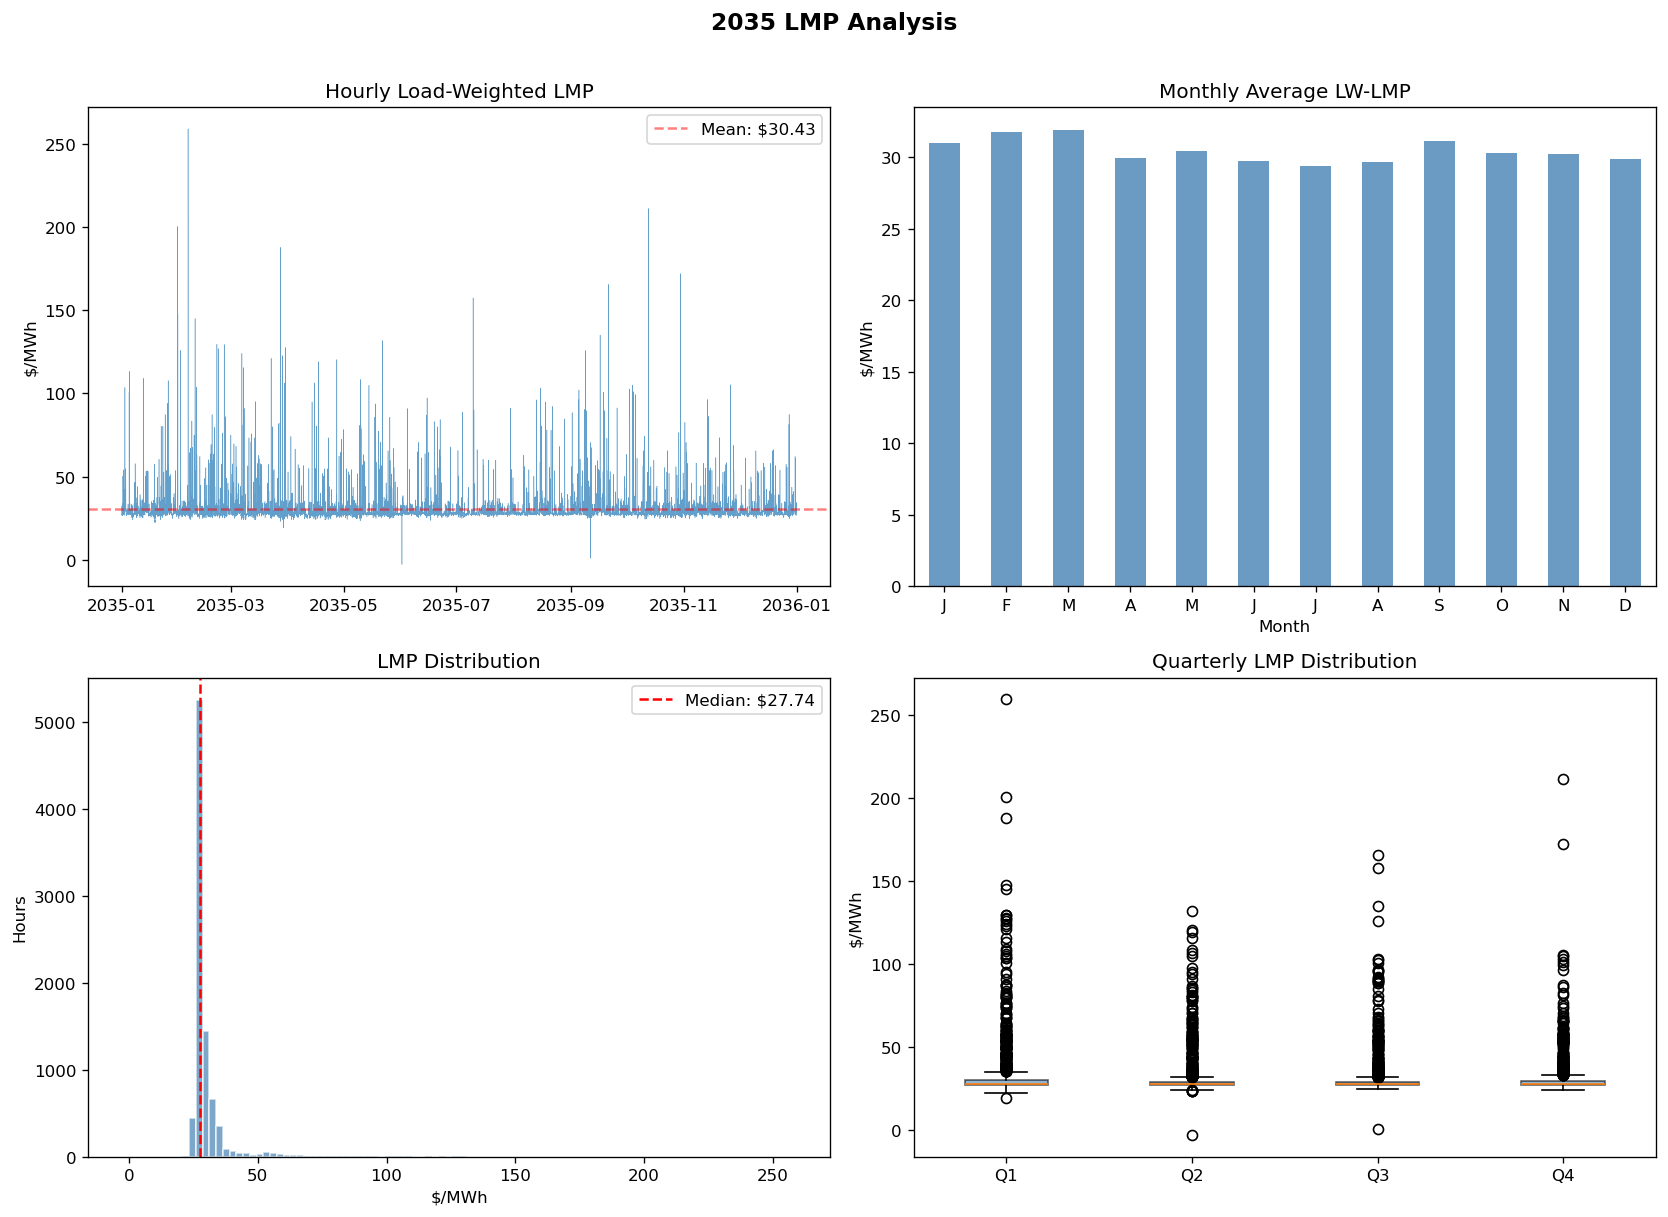

In [9]:
# ── System-level hourly load-weighted LMP (vectorized) ────────────────────
bus_df['_wt_lmp'] = bus_df['Demand'] * bus_df['LMP DA']
sys_hourly = bus_df.groupby('Datetime').agg(
    sys_demand=('Demand', 'sum'),
    sys_overgen=('Overgeneration', 'sum'),
    sys_shortfall=('Shortfall', 'sum'),
    _wt_lmp_sum=('_wt_lmp', 'sum'),
).reset_index()

sys_hourly['LW_LMP'] = sys_hourly['_wt_lmp_sum'] / sys_hourly['sys_demand']
_low = sys_hourly['sys_demand'] < _LOW_DEMAND_MW
if _low.any():
    warnings.warn(f'{_low.sum()} hour(s) with total demand < {_LOW_DEMAND_MW} MW')
    sys_hourly.loc[_low, 'LW_LMP'] = 0
sys_hourly['LW_LMP'] = sys_hourly['LW_LMP'].fillna(0)
sys_hourly.drop(columns='_wt_lmp_sum', inplace=True)
bus_df.drop(columns='_wt_lmp', inplace=True)

sys_hourly['Month'] = sys_hourly['Datetime'].dt.month
sys_hourly['Quarter'] = sys_hourly['Datetime'].dt.quarter
sys_hourly['Hour'] = sys_hourly['Datetime'].dt.hour

# ── Summary stats ─────────────────────────────────────────────────────────
print('Load-Weighted LMP Summary ($/MWh)')
print('=' * 45)
print(f'  Annual mean:   ${sys_hourly["LW_LMP"].mean():>8.2f}')
print(f'  Median:        ${sys_hourly["LW_LMP"].median():>8.2f}')
print(f'  Std dev:       ${sys_hourly["LW_LMP"].std():>8.2f}')
print(f'  Min:           ${sys_hourly["LW_LMP"].min():>8.2f}')
print(f'  Max:           ${sys_hourly["LW_LMP"].max():>8.2f}')
neg_count = (sys_hourly['LW_LMP'] < 0).sum()
print(f'  Negative hours: {neg_count} ({neg_count/len(sys_hourly)*100:.2f}%)')

# Monthly average
monthly_lmp = sys_hourly.groupby('Month')['LW_LMP'].mean()
print('\nMonthly Average LW-LMP ($/MWh):')
for m, v in monthly_lmp.items():
    print(f'  Month {m:>2d}: ${v:.2f}')

# ── 4-panel LMP figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly timeseries
ax = axes[0, 0]
ax.plot(sys_hourly['Datetime'], sys_hourly['LW_LMP'], linewidth=0.3, alpha=0.7)
ax.set_title('Hourly Load-Weighted LMP')
ax.set_ylabel('$/MWh')
ax.axhline(y=sys_hourly['LW_LMP'].mean(), color='red', linestyle='--', alpha=0.5,
           label=f'Mean: ${sys_hourly["LW_LMP"].mean():.2f}')
ax.legend()

# Monthly bars
ax = axes[0, 1]
monthly_lmp.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Monthly Average LW-LMP')
ax.set_ylabel('$/MWh')
ax.set_xlabel('Month')
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'], rotation=0)

# Histogram
ax = axes[1, 0]
ax.hist(sys_hourly['LW_LMP'], bins=100, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_title('LMP Distribution')
ax.set_xlabel('$/MWh')
ax.set_ylabel('Hours')
ax.axvline(x=sys_hourly['LW_LMP'].median(), color='red', linestyle='--',
           label=f'Median: ${sys_hourly["LW_LMP"].median():.2f}')
ax.legend()

# Quarterly boxplot
ax = axes[1, 1]
q_data = [sys_hourly[sys_hourly['Quarter'] == q]['LW_LMP'].values for q in [1, 2, 3, 4]]
bp = ax.boxplot(q_data, labels=['Q1', 'Q2', 'Q3', 'Q4'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_title('Quarterly LMP Distribution')
ax.set_ylabel('$/MWh')

plt.suptitle('2035 LMP Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.1 Quarterly Hourly Profiles

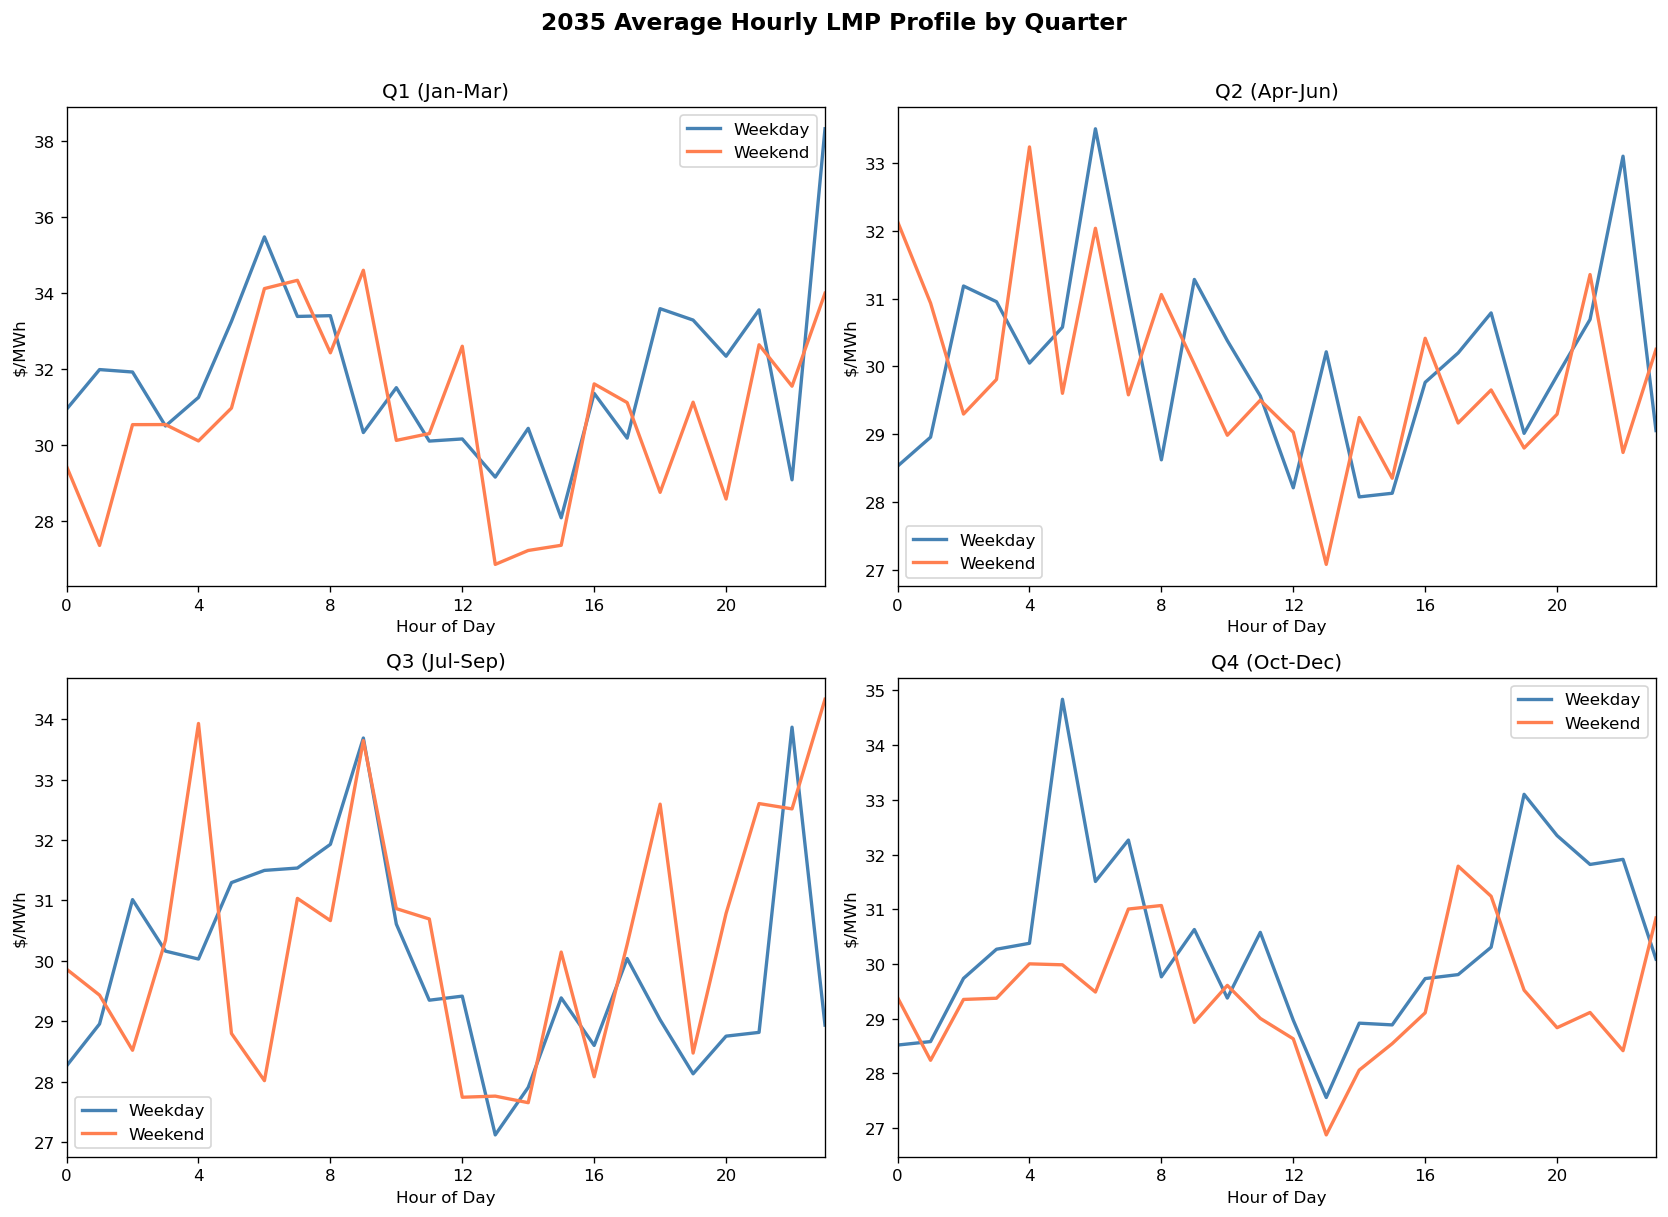

In [10]:
# ── Average hourly LMP profile by quarter, weekday vs weekend ─────────────
sys_hourly['DayOfWeek'] = sys_hourly['Datetime'].dt.dayofweek
sys_hourly['IsWeekend'] = sys_hourly['DayOfWeek'] >= 5

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
quarter_names = {1: 'Q1 (Jan-Mar)', 2: 'Q2 (Apr-Jun)',
                 3: 'Q3 (Jul-Sep)', 4: 'Q4 (Oct-Dec)'}

for idx, q in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2, idx % 2]
    q_data = sys_hourly[sys_hourly['Quarter'] == q]

    weekday = q_data[~q_data['IsWeekend']].groupby('Hour')['LW_LMP'].mean()
    weekend = q_data[q_data['IsWeekend']].groupby('Hour')['LW_LMP'].mean()

    ax.plot(weekday.index, weekday.values, label='Weekday', color='steelblue', linewidth=2)
    ax.plot(weekend.index, weekend.values, label='Weekend', color='coral', linewidth=2)
    ax.set_title(quarter_names[q])
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('$/MWh')
    ax.legend()
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 4))

plt.suptitle('2035 Average Hourly LMP Profile by Quarter', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Negative LMP Investigation

In [11]:
# ── Negative LMP analysis ─────────────────────────────────────────────────
neg_bus = bus_df[bus_df['LMP DA'] < 0].copy()
total_bus_hours = len(bus_df)
neg_bus_hours = len(neg_bus)

print('Negative LMP Analysis (DA)')
print('=' * 55)
print(f'  Bus-hours with negative LMP: {neg_bus_hours:,} / {total_bus_hours:,} ({neg_bus_hours/total_bus_hours*100:.3f}%)')
print(f'  System-hours with negative LW-LMP: {neg_count} / {len(sys_hourly)} ({neg_count/len(sys_hourly)*100:.3f}%)')

if neg_bus_hours > 0:
    neg_bus['Month'] = neg_bus['Datetime'].dt.month
    neg_bus['Hour'] = neg_bus['Datetime'].dt.hour

    print('\nNegative LMP by bus (top 10):')
    neg_by_bus = neg_bus.groupby('Bus').size().sort_values(ascending=False).head(10)
    for bus, cnt in neg_by_bus.items():
        print(f'  Bus {bus}: {cnt} hours')

    print('\nNegative LMP by month:')
    neg_by_month = neg_bus.groupby('Month').size()
    for m, cnt in neg_by_month.items():
        print(f'  Month {m:>2d}: {cnt:>6,} bus-hours')

    print('\nNegative LMP by hour of day:')
    neg_by_hour = neg_bus.groupby('Hour').size()
    for h, cnt in neg_by_hour.items():
        print(f'  Hour {h:>2d}: {cnt:>6,} bus-hours')

    print(f'\nMin negative LMP: ${neg_bus["LMP DA"].min():.2f}/MWh')
    print(f'Mean negative LMP: ${neg_bus["LMP DA"].mean():.2f}/MWh')
else:
    print('\nNo negative LMPs observed.')
    print('This is expected given NUC/COAL have zero dispatch (no minimum-load forcing).')

Negative LMP Analysis (DA)
  Bus-hours with negative LMP: 2,272 / 1,077,480 (0.211%)
  System-hours with negative LW-LMP: 1 / 8760 (0.011%)

Negative LMP by bus (top 10):
  Bus Plano 2 345: 189 hours
  Bus Coppell 345: 174 hours
  Bus Trent 2 345: 172 hours
  Bus Merkel 2 345: 172 hours
  Bus Eastland 345: 164 hours
  Bus Abilene 2 345: 137 hours
  Bus Abilene 5 345: 137 hours
  Bus Monahans 2 345: 106 hours
  Bus Mccamey 345: 106 hours
  Bus Alpine 2 345: 106 hours

Negative LMP by month:
  Month  1:    106 bus-hours
  Month  2:    261 bus-hours
  Month  3:    393 bus-hours
  Month  4:    195 bus-hours
  Month  5:    302 bus-hours
  Month  6:    225 bus-hours
  Month  7:    135 bus-hours
  Month  8:    111 bus-hours
  Month  9:    259 bus-hours
  Month 10:    129 bus-hours
  Month 11:    103 bus-hours
  Month 12:     53 bus-hours

Negative LMP by hour of day:
  Hour  0:    121 bus-hours
  Hour  1:    132 bus-hours
  Hour  2:     89 bus-hours
  Hour  3:     82 bus-hours
  Hour  4:    1

## 8. Marginal Cost Validation

In [12]:
# ── Marginal cost validation ──────────────────────────────────────────────
gen_info['expected_mc'] = gen_info['Fuel Price $/MMBTU'] * gen_info['HR_incr_1'] * 0.001

dispatching = therm_merged[therm_merged['Dispatch'] > 0.1].copy()
dispatching['observed_mc'] = dispatching['Unit Cost'] / dispatching['Dispatch']

mc_summary = dispatching.groupby('Unit Type').agg(
    count=('observed_mc', 'size'),
    obs_mc_mean=('observed_mc', 'mean'),
    obs_mc_median=('observed_mc', 'median'),
    obs_mc_std=('observed_mc', 'std'),
    total_gen_gwh=('Dispatch', lambda x: x.sum() / 1e3),
).round(2)

print('Marginal Cost Validation by Unit Type')
print('=' * 80)
print(mc_summary.to_string())

# ── Check expected MC ─────────────────────────────────────────────────────
expected_mc = {'NUC': 7.38, 'COAL': 18.94, 'CT': 22.80}
print('\n── Validation ──')
for utype, exp in expected_mc.items():
    if utype in mc_summary.index:
        obs = mc_summary.loc[utype, 'obs_mc_median']
        pct_err = abs(obs - exp) / exp * 100
        status = 'PASS' if pct_err < 20 else 'FAIL'
        print(f'  {status} {utype}: observed ${obs:.2f} vs expected ${exp:.2f} ({pct_err:.1f}% diff)')
    else:
        print(f'  SKIP {utype}: no dispatching hours (zero dispatch due to HR_avg_0 corruption)')

Marginal Cost Validation by Unit Type
            count  obs_mc_mean  obs_mc_median  obs_mc_std  total_gen_gwh
Unit Type                                                               
CT         322928        29.57          27.04        13.1      168915.98

── Validation ──
  SKIP NUC: no dispatching hours (zero dispatch due to HR_avg_0 corruption)
  SKIP COAL: no dispatching hours (zero dispatch due to HR_avg_0 corruption)
  PASS CT: observed $27.04 vs expected $22.80 (18.6% diff)


## 9. Transmission Congestion

In [13]:
# ── Load line_detail.csv (deferred to save memory) ────────────────────────
print('Loading line_detail.csv (large file, may take a moment)...')
line_df = _prescient_output_to_df(RESULTS_DIR / 'line_detail.csv')
print(f'Line detail rows: {len(line_df):,}')

# Line utilization — count hours with violations
violations = line_df[line_df['Violation'] > 0]
print(f'\nTotal violation events: {len(violations):,}')
print(f'Lines with violations: {violations["Line"].nunique()}')

# Top 20 congested lines by absolute flow
line_stats = line_df.groupby('Line').agg(
    mean_abs_flow=('Flow', lambda x: x.abs().mean()),
    max_abs_flow=('Flow', lambda x: x.abs().max()),
    violation_hours=('Violation', lambda x: (x > 0).sum()),
    total_violation_mw=('Violation', 'sum'),
).sort_values('max_abs_flow', ascending=False)

print('\nTop 20 Lines by Maximum Absolute Flow:')
print(line_stats.head(20).to_string())

if len(violations) > 0:
    print('\nTop 10 Lines by Violation Hours:')
    print(line_stats.sort_values('violation_hours', ascending=False).head(10).to_string())

# ── Quarterly congestion comparison ───────────────────────────────────────
line_df['Quarter'] = line_df['Datetime'].dt.quarter
q_violations = line_df.groupby('Quarter')['Violation'].agg(
    violation_count=lambda x: (x > 0).sum(),
    total_violation_mw='sum'
)
print('\nQuarterly Congestion Summary:')
print(q_violations.to_string())

# Free memory
del line_df
print('\nline_df released from memory.')

Loading line_detail.csv (large file, may take a moment)...


Line detail rows: 2,233,800

Total violation events: 0
Lines with violations: 0

Top 20 Lines by Maximum Absolute Flow:
       mean_abs_flow  max_abs_flow  violation_hours  total_violation_mw
Line                                                                   
152.0     425.986113   1326.577760                0                 0.0
166.0     750.947405   1326.577760                0                 0.0
74.0      626.340009   1326.577760                0                 0.0
101.0     571.733996   1218.352534                0                 0.0
188.0     510.298344   1207.066250                0                 0.0
104.0     630.318089   1207.066250                0                 0.0
53.0      630.802751   1207.066250                0                 0.0
189.0     302.459157   1207.066250                0                 0.0
133.0     856.933248   1207.066250                0                 0.0
62.0      358.126017   1199.799464                0                 0.0
93.0      444.00

## 10. Supply-Demand Balance & Reserve Adequacy

In [ ]:
# ── Hourly supply-demand balance ──────────────────────────────────────────
hourly_gen = _prescient_output_to_df(RESULTS_DIR / 'hourly_gen_summary.csv')

print('Supply-Demand Balance')
print('=' * 55)
print(f'  Hours with load shedding > 0: {(hourly_gen["Load shedding"] > 0).sum()}')
print(f'  Total load shedding: {hourly_gen["Load shedding"].sum():.2f} MWh')
print(f'  Max hourly load shedding: {hourly_gen["Load shedding"].max():.2f} MW')
print(f'  Hours with over-generation > 0: {(hourly_gen["Over generation"] > 0).sum()}')

# Reserve shortfall analysis
print('\nReserve Adequacy')
print('=' * 55)
shortfall_hours = hourly_gen[hourly_gen['Reserve shortfall'] > 0]
print(f'  Hours with reserve shortfall: {len(shortfall_hours)}')
print(f'  Total reserve shortfall: {hourly_gen["Reserve shortfall"].sum():.2f} MWh')

if len(shortfall_hours) > 0:
    shortfall_hours = shortfall_hours.copy()
    shortfall_hours['Month'] = shortfall_hours['Datetime'].dt.month
    shortfall_hours['Hour'] = shortfall_hours['Datetime'].dt.hour
    print(f'  Max hourly shortfall: {shortfall_hours["Reserve shortfall"].max():.2f} MW')
    print(f'  Mean shortfall (when > 0): {shortfall_hours["Reserve shortfall"].mean():.2f} MW')

    print('\n  Shortfall by month:')
    sf_by_month = shortfall_hours.groupby('Month')['Reserve shortfall'].agg(['count', 'sum']).round(1)
    sf_by_month.columns = ['Hours', 'Total (MWh)']
    print(sf_by_month.to_string())

    print('\n  Shortfall by hour of day:')
    sf_by_hour = shortfall_hours.groupby('Hour')['Reserve shortfall'].agg(['count', 'sum']).round(1)
    sf_by_hour.columns = ['Hours', 'Total (MWh)']
    print(sf_by_hour.to_string())

# ── Supply vs demand plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sys_hourly['Datetime'], sys_hourly['sys_demand'], linewidth=0.5, alpha=0.7, label='Demand')
if (hourly_gen['Load shedding'] > 0).any():
    shed_idx = hourly_gen[hourly_gen['Load shedding'] > 0].index
    shed_demand = sys_hourly.iloc[shed_idx]['sys_demand'].values
    shed_times = sys_hourly.iloc[shed_idx]['Datetime'].values
    ax.scatter(shed_times, shed_demand, color='red', s=20, zorder=5, label='Load Shedding')
ax.set_ylabel('MW')
ax.set_title('2035 System Demand (Hourly)')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

## 11. 2035 vs 2019 Baseline Comparison

Comparison with the 2019 baseline (PTDF 90-day simulation from `prescient_lmp_analysis.ipynb`).

> **Caveat:** The 2035 results are distorted by the NUC/COAL zero-dispatch issue.
> True 2035 LMPs would likely be lower with proper NUC baseload dispatch.

In [15]:
# ── 2035 vs 2019 comparison table ─────────────────────────────────────────
# 2019 baseline values (from prescient_lmp_analysis.ipynb, 90-day)
baseline_2019 = {
    'Simulation Period': ('90 days (Q1)', '365 days (full year)'),
    'Formulation': ('PTDF', 'PTDF'),
    'Generators': (282, 278),
    'Load-Weighted LMP ($/MWh)': (24.73, round(lw_lmp, 2)),
    'Renewables Penetration (%)': (27.5, round(o['Overall renewables penetration rate'], 1)),
    'Total Costs ($B, annualized)': ('N/A (90-day)', round(o['Total costs'] / 1e9, 2)),
    'Load Shedding (MWh)': (0, round(o['Total load shedding'], 2)),
    'Curtailment (MWh)': (0, round(o['Total renewables curtailment'], 2)),
    'NUC Dispatch': ('Active', 'ZERO (HR_avg_0 bug)'),
    'COAL Dispatch': ('Active', 'ZERO (HR_avg_0 bug)'),
}

print('2035 vs 2019 Baseline Comparison')
print('=' * 75)
print(f'{"Metric":<35s} {"2019 Baseline":>18s} {"2035 GTEP":>18s}')
print('-' * 75)
for k, (v19, v35) in baseline_2019.items():
    print(f'{k:<35s} {str(v19):>18s} {str(v35):>18s}')

# Fleet evolution
print('\n── Fleet Evolution ──')
gen_type_counts = gen.groupby('Unit Type').size()
gen_cap = gen.groupby('Unit Type')['PMax MW'].sum()
print(f'{"Type":<8s} {"Count":>8s} {"Capacity (MW)":>14s}')
print('-' * 34)
for ut in sorted(gen_type_counts.index):
    print(f'{ut:<8s} {gen_type_counts[ut]:>8d} {gen_cap[ut]:>14,.0f}')
print('-' * 34)
print(f'{"TOTAL":<8s} {gen_type_counts.sum():>8d} {gen_cap.sum():>14,.0f}')

2035 vs 2019 Baseline Comparison
Metric                                   2019 Baseline          2035 GTEP
---------------------------------------------------------------------------
Simulation Period                         90 days (Q1) 365 days (full year)
Formulation                                       PTDF               PTDF
Generators                                         282                278
Load-Weighted LMP ($/MWh)                        24.73              30.48
Renewables Penetration (%)                        27.5               29.2
Total Costs ($B, annualized)              N/A (90-day)               4.84
Load Shedding (MWh)                                  0               3.45
Curtailment (MWh)                                    0                0.0
NUC Dispatch                                    Active ZERO (HR_avg_0 bug)
COAL Dispatch                                   Active ZERO (HR_avg_0 bug)

── Fleet Evolution ──
Type        Count  Capacity (MW)
-----------------

## 12. Computational Performance

Computational Performance

SCED Solve Times (seconds):
  Count:  8,760


  Mean:   0.037
  Median: 0.036
  Max:    0.076
  Std:    0.006

RUC Solve Times (seconds):
  Count:  0
  Mean:   nan
  Median: nan
  Max:    nan
  Std:    nan

Total solver time: 323 s (0.1 hours)


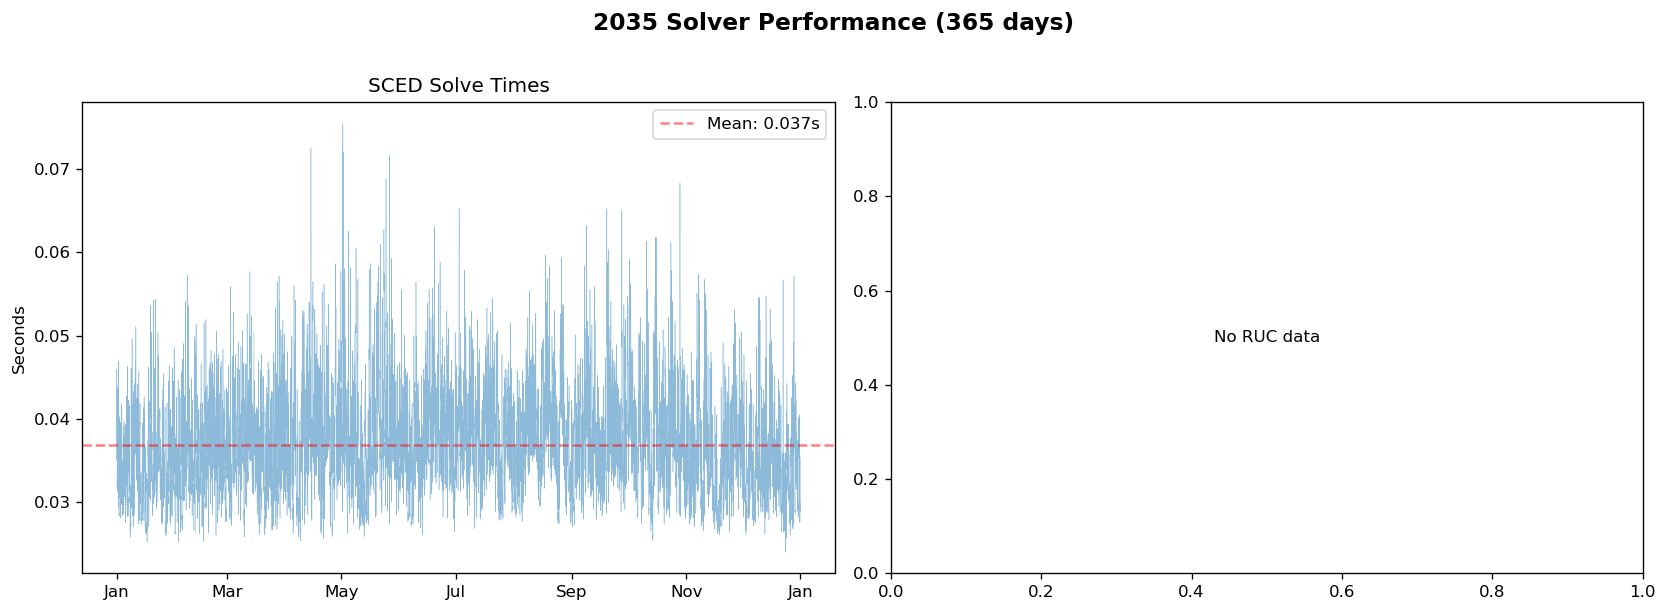

In [16]:
# ── Runtimes analysis ─────────────────────────────────────────────────────
runtimes = _prescient_output_to_df(RESULTS_DIR / 'runtimes.csv')

sced_times = runtimes[runtimes['Type'] == 'SCED']['Solve Time']
ruc_times = runtimes[runtimes['Type'] == 'RUC']['Solve Time']

print('Computational Performance')
print('=' * 55)
print(f'\nSCED Solve Times (seconds):')
print(f'  Count:  {len(sced_times):,}')
print(f'  Mean:   {sced_times.mean():.3f}')
print(f'  Median: {sced_times.median():.3f}')
print(f'  Max:    {sced_times.max():.3f}')
print(f'  Std:    {sced_times.std():.3f}')

print(f'\nRUC Solve Times (seconds):')
print(f'  Count:  {len(ruc_times):,}')
print(f'  Mean:   {ruc_times.mean():.3f}')
print(f'  Median: {ruc_times.median():.3f}')
print(f'  Max:    {ruc_times.max():.3f}')
print(f'  Std:    {ruc_times.std():.3f}')

total_wall = sced_times.sum() + ruc_times.sum()
print(f'\nTotal solver time: {total_wall:.0f} s ({total_wall/3600:.1f} hours)')

# ── Runtime plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sced_rt = runtimes[runtimes['Type'] == 'SCED'].copy()
ruc_rt = runtimes[runtimes['Type'] == 'RUC'].copy()

ax = axes[0]
ax.plot(sced_rt['Datetime'], sced_rt['Solve Time'], linewidth=0.3, alpha=0.5)
ax.set_title('SCED Solve Times')
ax.set_ylabel('Seconds')
ax.axhline(y=sced_times.mean(), color='red', linestyle='--', alpha=0.5,
           label=f'Mean: {sced_times.mean():.3f}s')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax = axes[1]
if len(ruc_rt) > 0:
    ax.plot(ruc_rt['Datetime'], ruc_rt['Solve Time'], 'o-', markersize=2, linewidth=0.5)
    ax.set_title('RUC Solve Times')
    ax.set_ylabel('Seconds')
    ax.axhline(y=ruc_times.mean(), color='red', linestyle='--', alpha=0.5,
               label=f'Mean: {ruc_times.mean():.3f}s')
    ax.legend()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
else:
    ax.text(0.5, 0.5, 'No RUC data', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('2035 Solver Performance (365 days)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13. Key Findings & Recommendations

### Summary

The 365-day 2035 GTEP Stage 3 Prescient simulation completed successfully across all
8,760 hours with minimal load shedding (3.4 MWh) and zero curtailment.

### Critical Issue

- **NUC/COAL zero dispatch**: The `HR_avg_0` column in `gen.csv` contains corrupted values
  (NUC: 3.6M–4.0M, COAL: 35K–309K vs CT: 3K–9K normal). This makes Egret compute
  prohibitive startup costs, preventing any NUC or COAL commitment.
- **Impact**: The generation mix is entirely CT + renewables, overstating gas generation
  and LMP. The $20.27/MWh average price is biased high relative to what a correct mix
  with NUC baseload would produce.

### Observations (with caveats)

1. **LMP**: Load-weighted average ~$20/MWh, driven by CT marginal cost (~$22.80/MWh)
2. **Renewables**: 29.2% penetration — PV and WIND provide significant generation
3. **Reliability**: Near-zero load shedding, minimal reserve shortfall (591 MWh)
4. **Congestion**: See Section 9 for line utilization details

### Recommendations

1. **Fix HR_avg_0** in `gen.csv` for NUC and COAL generators, then re-run
2. Once fixed, expect NUC to dominate baseload, significantly reducing LMP
3. Coal dispatch will depend on relative fuel prices vs gas
4. Results from this run are useful for CT and renewable validation only

### Go/No-Go

- **GO** for CT + renewable dispatch validation
- **NO-GO** for publication-quality LMP or generation mix results until HR_avg_0 is fixed